# Threshold Tuning, Part B — Weighing Errors by Cost

In [part A](09a_threshold_tuning.ipynb) we tuned the decision threshold with a *recall-first* rule: catch **every** positive case, then minimise false alarms. That rule is the right one when a miss is unacceptable but hard to price.

Often, though, you *can* put a number on the damage:

- A missed diabetic patient (**false negative**) leads to a delayed diagnosis — expensive and dangerous.
- A false alarm (**false positive**) only triggers a follow-up test — a real but smaller cost.

When you can say *"a false negative is 5× as costly as a false positive"*, you no longer need an arbitrary recall target. You pick the threshold that **minimises the total business cost**.

This notebook:

- Reuses the Pima diabetes setup from part A so it reads as a sequel.
- Encodes a constant `FN:FP` cost ratio as a custom scorer.
- Lets scikit-learn's [`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html) search the threshold that maximises the resulting gain.


In [1]:
# https://pandas.pydata.org/docs/
import pandas as pd

# https://numpy.org/doc/stable/
import numpy as np

# https://matplotlib.org/
import matplotlib.pyplot as plt

# https://seaborn.pydata.org/
import seaborn as sns

# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html
from sklearn.datasets import fetch_openml

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html
from sklearn.model_selection import train_test_split, TunedThresholdClassifierCV

# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
from sklearn.preprocessing import StandardScaler

# https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
from sklearn.linear_model import LogisticRegression

# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html
from sklearn.pipeline import make_pipeline

# https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
)

sns.set_theme(style="whitegrid")

## Load data and split

We reuse the [Pima Indians Diabetes](https://www.openml.org/d/37) dataset from part A: eight routine health measurements, with `tested_positive` as the class we must not miss.


In [2]:
diabetes = fetch_openml("diabetes", version=1, as_frame=True)
X_diabetes = diabetes.data

# Positive class = tested_positive (the case a false negative misses)
y_diabetes = (diabetes.target == "tested_positive").astype(int)

print(f"Samples: {X_diabetes.shape[0]:,}")
print(f"Positive rate: {y_diabetes.mean():.1%}")

X_train_dia, X_test_dia, y_train_dia, y_test_dia = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.25,  # hold out 25% for evaluation
    random_state=42,
    stratify=y_diabetes,  # keep the same positive rate in train and test
)

Samples: 768
Positive rate: 34.9%


## Fit the model

A scaler plus logistic regression — identical to part A. The threshold tuning we do later is independent of *which* model we fit; it only reshapes how the model's probabilities become decisions.


In [3]:
model_dia = make_pipeline(
    StandardScaler(),  # scale features so logistic regression converges
    LogisticRegression(max_iter=1000, random_state=42),
)
model_dia.fit(X_train_dia, y_train_dia)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['preg','plas','pres',...,'mass','pedi','age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Define the business cost

We encode the clinical judgement that **a false negative is 5× as costly as a false positive** in a *gain matrix*:

- Rows are the true class, columns are the predicted class, in the order `[negative, positive]`.
- A false positive (top-right) costs `-1`; a false negative (bottom-left) costs `-5`.
- Correct predictions cost `0`.

scikit-learn's model-selection tools follow a *"higher is better"* convention, so we express cost as a **negative gain**. Summing the confusion matrix multiplied element-wise by the gain matrix gives the total gain — and the threshold that maximises it is the one that minimises cost.


In [4]:
COST_FP = 1  # a false alarm: an unnecessary follow-up test
COST_FN = 5  # a missed diabetic patient: five times more damaging

gain_matrix = np.array(
    [
        [0, -COST_FP],  # true negative = 0, false positive = -1
        [-COST_FN, 0],  # false negative = -5, true positive = 0
    ]
)


def cost_score(y_true, y_pred):
    """Total gain (negative cost). Higher is better, so 0 is the ideal."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return np.sum(cm * gain_matrix)


# make_scorer wraps our function so TunedThresholdClassifierCV can evaluate it.
# greater_is_better=True because cost_score already returns a (negative) gain.
cost_scorer = make_scorer(cost_score, greater_is_better=True)

## Cost at the default 0.5 threshold

Before tuning, we measure what the default threshold costs us. We count false positives and false negatives on the test set and turn them into a single euro-like figure with the 5:1 ratio.


In [5]:
y_pred_default = model_dia.predict(X_test_dia)

# confusion_matrix already counts the four outcomes; ravel() flattens it to
# (true negative, false positive, false negative, true positive).
_, fp_default, fn_default, _ = confusion_matrix(
    y_test_dia, y_pred_default, labels=[0, 1]
).ravel()

# Reuse the scorer instead of re-deriving the arithmetic: it returns a
# (negative) gain, so the cost is simply its negation.
total_cost_default = -cost_score(y_test_dia, y_pred_default)

print("Default threshold = 0.5")
print(f"  False positives: {fp_default}")
print(f"  False negatives: {fn_default}")
print(f"  Total cost:      {total_cost_default}")

Default threshold = 0.5
  False positives: 19
  False negatives: 32
  Total cost:      179


## Tune the threshold

Instead of scanning thresholds by hand, [`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html) searches the decision threshold by cross-validation, optimising the cost scorer we just defined:

- `cv=5` evaluates each candidate threshold with 5-fold stratified cross-validation.
- `store_cv_results=True` keeps the score at every threshold so we can plot the objective curve later.
- The fitted object exposes `best_threshold_` and a `predict` that already applies it.


In [ ]:
tuned_dia = TunedThresholdClassifierCV(
    estimator=model_dia,  # cloned and refit inside the cross-validation
    scoring=cost_scorer,  # maximise gain = minimise the 5:1 cost
    cv=5,  # 5-fold stratified CV to choose the threshold
    store_cv_results=True,  # keep the score at every candidate threshold
)
tuned_dia.fit(X_train_dia, y_train_dia)

print( "Default threshold: 0.500")
print(f"Tuned threshold:   {tuned_dia.best_threshold_:.3f}")

Default threshold: 0.500
Tuned threshold:   0.129


## Compare default vs tuned

We now line up the two operating points: the cost table, the confusion matrices, and the objective curve that explains *why* the tuner landed where it did.


In [7]:
y_pred_tuned = tuned_dia.predict(X_test_dia)

_, fp_tuned, fn_tuned, _ = confusion_matrix(
    y_test_dia, y_pred_tuned, labels=[0, 1]
).ravel()
total_cost_tuned = -cost_score(y_test_dia, y_pred_tuned)

comparison = pd.DataFrame(
    {
        "False positives": [fp_default, fp_tuned],
        "False negatives": [fn_default, fn_tuned],
        "Total cost": [total_cost_default, total_cost_tuned],
    },
    index=["Default (0.5)", f"Tuned ({tuned_dia.best_threshold_:.3f})"],
)
comparison

,False positives,False negatives,Total cost
Default (0.5),19,32,179
Tuned (0.129),68,1,73


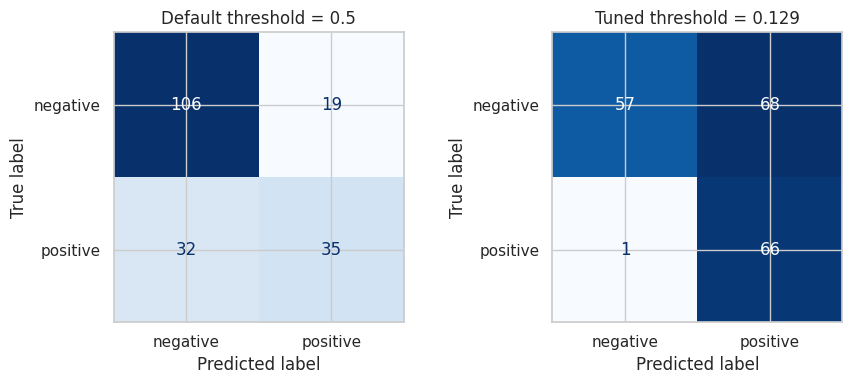

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, y_pred, title in [
    (axes[0], y_pred_default, "Default threshold = 0.5"),
    (axes[1], y_pred_tuned, f"Tuned threshold = {tuned_dia.best_threshold_:.3f}"),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test_dia,
        y_pred,
        display_labels=["negative", "positive"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(title)

fig.tight_layout()
plt.show()

### Objective score vs threshold

`store_cv_results=True` recorded the cross-validated gain at every candidate threshold. Plotting it shows a clear peak — the tuner simply picks its maximum.


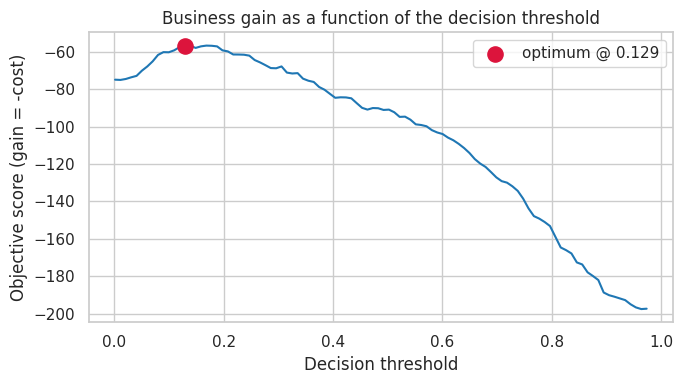

In [9]:
cv_results = tuned_dia.cv_results_

fig, ax = plt.subplots(figsize=(7, 4))

sns.lineplot(
    x=cv_results["thresholds"],
    y=cv_results["scores"],
    ax=ax,
    color="tab:blue",
)
ax.scatter(
    tuned_dia.best_threshold_,
    tuned_dia.best_score_,
    s=120,
    color="crimson",
    zorder=5,
    label=f"optimum @ {tuned_dia.best_threshold_:.3f}",
)
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Objective score (gain = -cost)")
ax.set_title("Business gain as a function of the decision threshold")
ax.legend()
fig.tight_layout()
plt.show()

## Recap

- **Part A** used a recall-first rule: catch every case, then minimise false alarms — ideal when a miss is unacceptable but hard to price.
- **Part B** prices the errors instead. A constant `FN:FP = 5:1` cost matrix turns threshold choice into a single cost-minimisation problem, solved by `TunedThresholdClassifierCV`.
- The tuned threshold drops well below `0.5`, trading extra false positives for fewer (costlier) false negatives, and lowers the total business cost.

Prefer a **cost scorer** over a fixed recall target whenever you can credibly quantify the relative damage of each error type.

Next, [part C](09c_threshold_tuning.ipynb) tackles the harder case where the cost is **not constant** — it varies with every individual transaction.
